In [65]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
from os.path import isfile, join
import pylab as plt
from glob import glob
import subprocess
import re
import math

import geopandas
from matplotlib_scalebar.scalebar import ScaleBar

from shapely import wkt

import seaborn as sns
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [2]:
rawDataDir = "/Users/swise/workspace/takamatsu/data/okazakiDemo/"
procDataDir = "/Users/swise/Projects/hitomi/data/transit/output/"

waterFloodedFile = rawDataDir + "simplifiedWater.shp"
roadsFile = rawDataDir + "simpleRoads_withInundation.shp"
stationsFile = rawDataDir + "trainStationsWithPassengers.shp"


In [47]:
# read in the list of files from the directory
workingDir = procDataDir
files = os.listdir(workingDir)
holder = {} # set up the holder
f = files[0]

In [5]:
roads = geopandas.read_file(roadsFile)
water = geopandas.read_file(waterFloodedFile)
stations = geopandas.read_file(stationsFile)

In [19]:
# helper function
def extractEvacTime(s):
    bits = s.split(',')
    record = {}
    for b in bits:
        try:
            k,v = b.split(':')
            if k[0] not in record:
                record[k] = float(v)
        except:
            pass

    if "START_EVACUATING" in record:
        startTime = record["START_EVACUATING"]
    else:
        startTime = record["START"]
    finishTime = 1440
    if "FINISH_EVAC" in record:
        finishTime = record["FINISH_EVAC"]
    elif "TRAPPED" in record:
        finishTime = record["TRAPPED"]
        
    return finishTime - startTime

In [50]:
evacueeFullData = []
evacuatingFullData = []
numTrapped = []

# extract them
for f in files:
    
    if not f.startswith("evac"):
        continue
    
    isHeatmap = "heatmap" in f
    if isHeatmap:
        continue
    
    raw_data = pd.DataFrame(pd.read_csv(workingDir + f, sep='\t')) # read in file
    
    # successful evacuees
    evacuees = raw_data[raw_data["status"] == "Evacuated"].reset_index()
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacueeFullData.append(evacTime)
    
    # incomplete evacuations
    evacuees = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    evacTime = [extractEvacTime(s) for s in evacuees["evacuatingRecord"]]
    evacuatingFullData.append(evacTime)
    
    # trapped
    trapped = raw_data[raw_data["status"] == "Evacuating"].reset_index()
    numTrapped.append(len(trapped))
    
#len(evacueeFullData)
print(numTrapped)
len(evacueeFullData[0])

[292, 243, 238, 250, 249, 278, 235, 262, 257, 288, 291, 246, 272, 272, 285, 265, 286, 258, 232, 239, 250, 259, 257, 230, 265, 233, 262, 240, 240, 292, 286, 263, 287, 274, 256, 246, 280, 284, 262, 256, 272, 260, 240, 274, 231, 262, 235]


4368

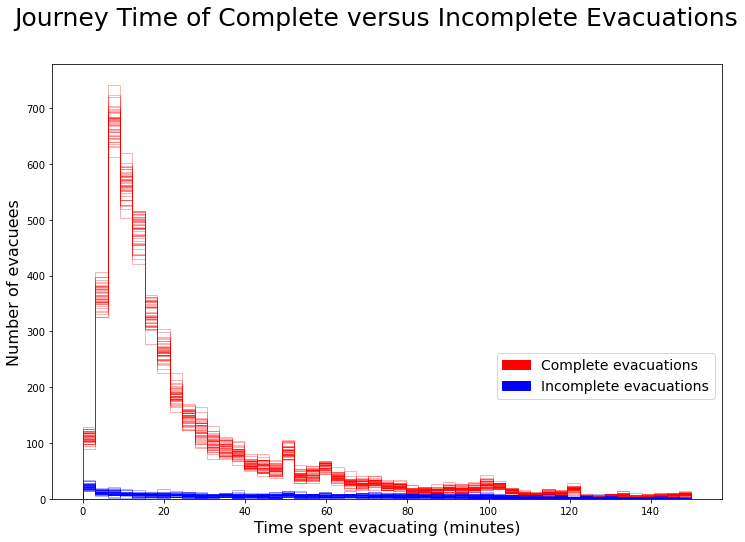

In [95]:
#fig, ax = plt.subplots(ncols=1, nrows = 1, sharex=True, sharey=True, figsize=(30,24))
bins = np.linspace(0, 150, 50)


fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111)

# Inset plot
#ax_inset = fig.add_axes([0.5, 0.5, 0.35, 0.3])

for inst in evacueeFullData:
    ax.hist(inst, bins, alpha=0.3, label="complete evacuation", color="red", histtype='step')
#    ax_inset.hist(inst, bins, alpha=0.3, color="red", log='y', histtype='step')
for inst in evacuatingFullData:
    ax.hist(inst, bins, alpha=0.3, label="incomplete evacuation", color="blue", histtype='step')
#    ax_inset.hist(inst, bins, alpha=0.3, color="blue", log='y', histtype='step')
ax.set_xlabel("Time spent evacuating (minutes)", fontsize=16)
ax.set_ylabel("Number of evacuees", fontsize=16)
#plt.legend(loc='upper right')

complete = mpatches.Patch(color='red', label='Complete evacuations')
incomplete = mpatches.Patch(color='blue', label='Incomplete evacuations')
ax.legend(handles=[complete, incomplete], fontsize=14, bbox_to_anchor=(0., 0.25, 1., .102))

#ax_inset.set_title("Log-scale evacuation durations")
#ax_inset.set_xlabel("minutes")
#ax_inset.set_ylabel("log(# of persons)")

plt.suptitle("Journey Time of Complete versus Incomplete Evacuations", fontsize=25)
#plt.tight_layout()
evacTimeFilename = "evacuationTimeDist_noInset.png"
plt.savefig(evacTimeFilename, format="png", dpi=720)